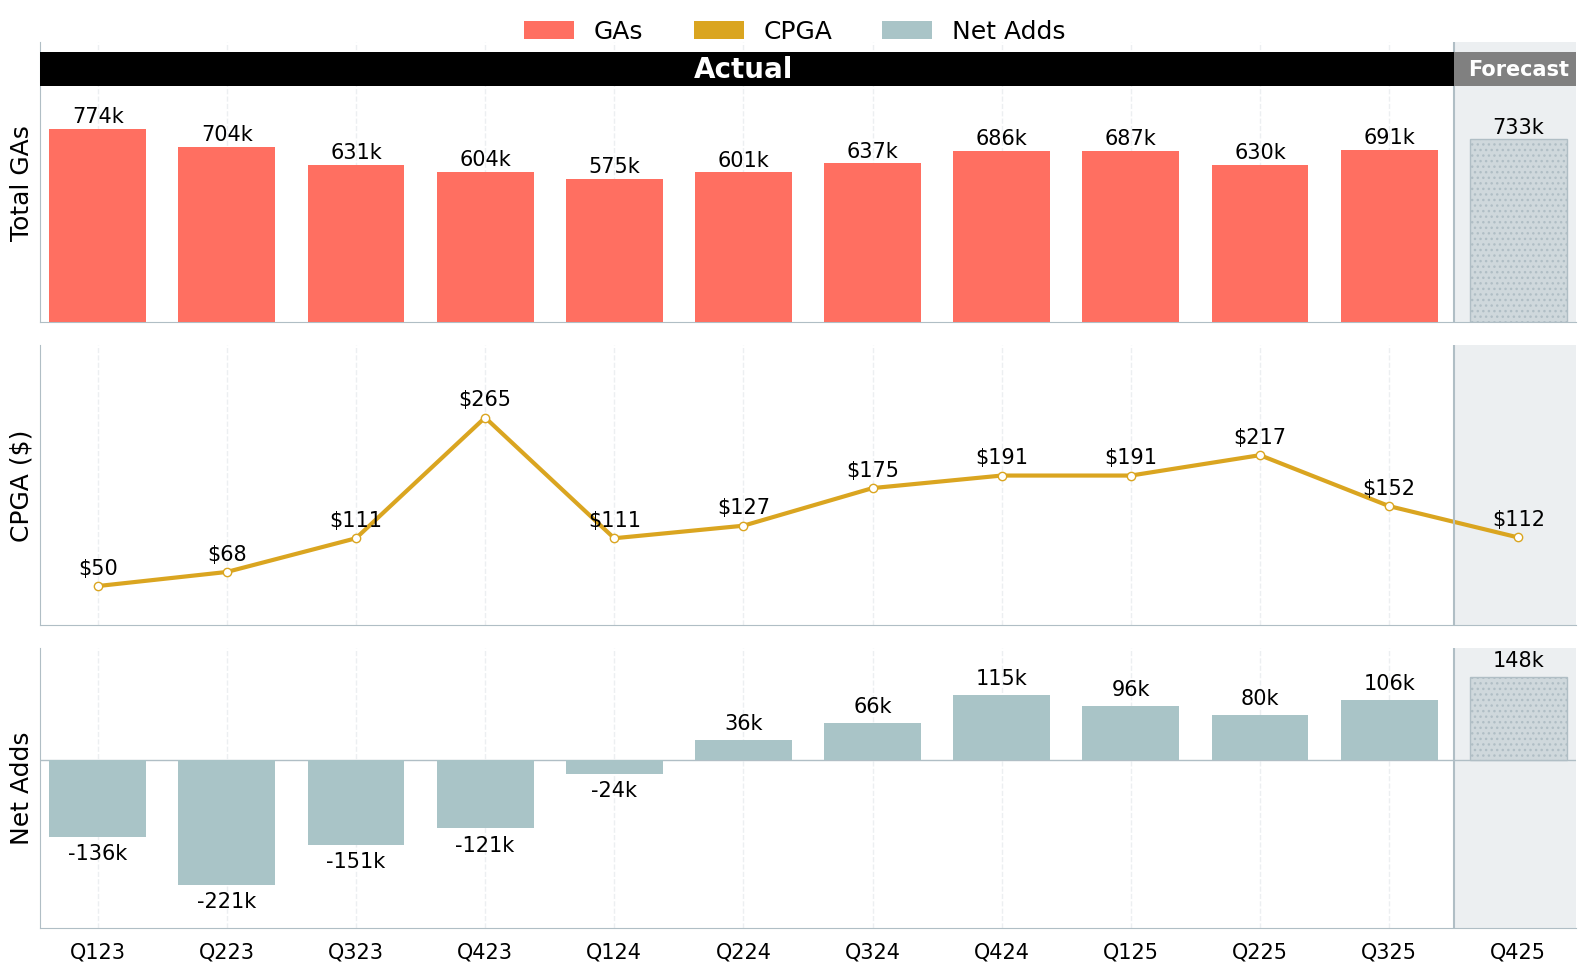

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch, Rectangle

# --- 1. Data ---
quarters = [
    'Q123', 'Q223', 'Q323', 'Q423', 'Q124', 'Q224',
    'Q324', 'Q424', 'Q125', 'Q225', 'Q325', 'Q425'
]

# Updated Q3-25 values:
#   Total GAs: 690,803  -> 691k on chart
#   Net Adds:  105,586  -> 106k on chart
#   CPGA:      $151.5
gas_k =     [774, 704, 631, 604, 575, 601, 637, 686, 687, 630, 691, 733]
cpga =      [ 50,  68, 111, 265, 111, 127, 175, 191, 191, 217, 152, 112]
net_adds_k =[ -136,-221,-151,-121, -24,  36,  66, 115,  96,  80, 106, 148]

# --- Parameters ---
# Q3-25 should no longer be in the forecast box -> mark it as actual
num_actual = 11
bar_width = 0.75

# --- Color Palette & Style ---
background_color = 'white'
ga_color = '#ff6f61'      # Salmon Red
cpga_color = '#daa520'    # Goldenrod
net_adds_color = '#a9c4c7' # Light Blue-Gray
text_color = 'black'
spine_color = '#b0bec5'
grid_color = '#eceff1'
forecast_span_color = '#eceff1'
forecast_bar_color = '#cfd8dc'

# --- 2. Setup Plot ---
num_total = len(quarters)
x_indices = np.arange(num_total)
split_point = num_actual - 0.5

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(16, 10),
    sharex=True,
    gridspec_kw={'height_ratios': [1, 1, 1]}
)
fig.patch.set_facecolor(background_color)

# --- 3. Top Plot: Total GAs ---
ax1.set_facecolor(background_color)
ax1.bar(x_indices[:num_actual], gas_k[:num_actual], color=ga_color, width=bar_width, zorder=3)
ax1.bar(x_indices[num_actual:], gas_k[num_actual:], color=forecast_bar_color, hatch='...', edgecolor=spine_color, width=bar_width, zorder=3)
ax1.set_ylabel('Total GAs', color=text_color, fontsize=18)
for i, val in enumerate(gas_k):
    ax1.text(i, val + 25, f'{val}k', ha='center', color=text_color, fontsize=15)

# --- 4. Middle Plot: CPGA ---
ax2.set_facecolor(background_color)
ax2.plot(x_indices, cpga, color=cpga_color, linewidth=3, marker='o', markersize=6, markerfacecolor=background_color, zorder=3)
ax2.set_ylabel('CPGA ($)', color=text_color, fontsize=18)
for i, val in enumerate(cpga):
    # Use general format so 151.5 shows as '151.5' and integers show without trailing '.0'
    ax2.text(i, val + 15, f'${val:g}', ha='center', color=text_color, fontsize=15)

# --- 5. Bottom Plot: Net Adds ---
ax3.set_facecolor(background_color)
ax3.bar(x_indices[:num_actual], net_adds_k[:num_actual], color=net_adds_color, width=bar_width, zorder=3)
ax3.bar(x_indices[num_actual:], net_adds_k[num_actual:], color=forecast_bar_color, hatch='...', edgecolor=spine_color, width=bar_width, zorder=3)
ax3.set_ylabel('Net Adds', color=text_color, fontsize=18)
ax3.axhline(0, color=spine_color, linewidth=1)
for i, val in enumerate(net_adds_k):
    y_pos = val + 12 if val >= 0 else val - 12
    va = 'bottom' if val >= 0 else 'top'
    ax3.text(i, y_pos, f'{val}k', ha='center', va=va, color=text_color, fontsize=15)

# --- 6. Styling and Formatting ---
header_y_start = max(gas_k) * 1.22
header_height = max(gas_k) * 0.18
header_text_y = header_y_start + (header_height / 2)

# "Actual" Header
rect_actual = Rectangle(xy=(-0.5, header_y_start), width=(split_point + 0.5), height=header_height,
                        facecolor='black', edgecolor='none', transform=ax1.transData, zorder=5)
ax1.add_patch(rect_actual)
actual_mid_x = (split_point - 0.5) / 2
ax1.text(actual_mid_x, header_text_y, 'Actual', ha='center', va='center', fontsize=20,
         color='white', fontweight='bold', zorder=6)

# "Forecast" Header (now only Q4-25)
forecast_header_width = (num_total - 0.5) - split_point
rect_forecast = Rectangle(xy=(split_point, header_y_start), width=forecast_header_width, height=header_height,
                          facecolor='#808080', edgecolor='none', transform=ax1.transData, zorder=5)
ax1.add_patch(rect_forecast)
forecast_mid_x = split_point + (forecast_header_width / 2)
ax1.text(forecast_mid_x, header_text_y, 'Forecast', ha='center', va='center', fontsize=15,
         color='white', fontweight='bold', zorder=6)

for ax in [ax1, ax2, ax3]:
    ax.set_axisbelow(True)
    ax.axvline(x=split_point, color=spine_color, linestyle='-', linewidth=1.5, zorder=4)
    ax.axvspan(split_point, num_total - 0.5, facecolor=forecast_span_color)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(spine_color)
    ax.get_yaxis().set_ticks([])
    ax.tick_params(axis='y', colors=text_color)
    ax.tick_params(axis='x', length=0, pad=10)
    ax.grid(True, axis='x', color=grid_color, linestyle='--', linewidth=1)
    ax.set_xlim(-0.45, num_total - 0.55)

ax1.set_ylim(0, max(gas_k) * 1.45)
ax2.set_ylim(0, max(cpga) * 1.35)
ax3.set_ylim(min(net_adds_k) * 1.35, max(net_adds_k) * 1.35)

plt.xticks(x_indices, quarters, fontsize=15, color=text_color)

legend_elements = [
    Patch(facecolor=ga_color, label='GAs'),
    Patch(facecolor=cpga_color, label='CPGA'),
    Patch(facecolor=net_adds_color, label='Net Adds')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 0.98), frameon=False,
           labelcolor=text_color, fontsize=18)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.08)
plt.show()


In [2]:
p = 690803 - 585217

print(p)

q = 104641099 / 690803

print(q)

105586
151.4774820028286
